<a href="https://colab.research.google.com/github/andrebrandaopro/Lista2/blob/Portf%C3%B3lio/q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualização de Quatro Distribuições Gaussianas 8D via Autoencoder

## Enunciado
Considere quatro distribuições gaussianas $C_1, C_2, C_3, C_4$ em um espaço de entrada de 8 dimensões ($\mathbb{R}^8$), com médias:
- $\mathbf{m}_1 = (0,0,0,0,0,0,0,0)^{\top}$
- $\mathbf{m}_2 = (4,0,0,0,0,0,0,0)^{\top}$
- $\mathbf{m}_3 = (0,0,0,4,0,0,0,0)^{\top}$
- $\mathbf{m}_4 = (0,0,0,0,0,0,0,4)^{\top}$

Variância unitária para todas as dimensões. Cada classe é uma nuvem de pontos ao redor de seu centro.

## Objetivo
1. Gerar amostras dessas quatro gaussianas em 8D.
2. Treinar um **autoencoder** para reduzir de 8D para 2D.
3. Visualizar os dados nesse novo espaço 2D.

---

## 1. Gerando os Dados Gaussianos em 8D

Cada classe terá 250 amostras (total: 1000 pontos), variância unitária em cada dimensão.

Shape dos dados: (1000, 8)


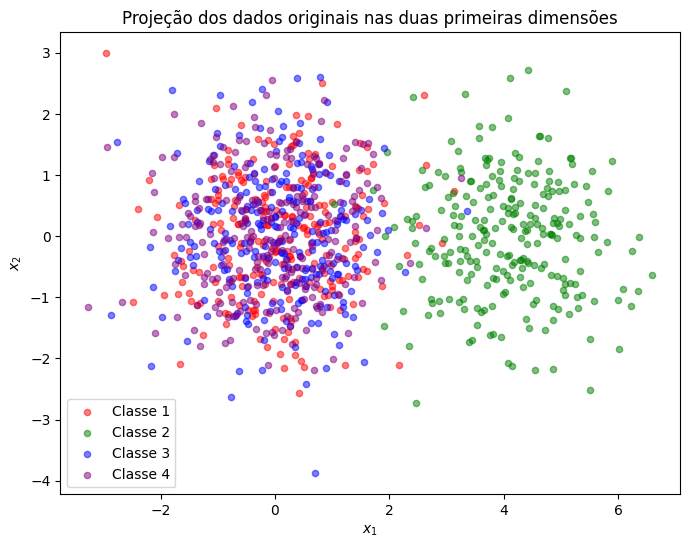

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Definindo médias
m1 = np.array([0,0,0,0,0,0,0,0])
m2 = np.array([4,0,0,0,0,0,0,0])
m3 = np.array([0,0,0,4,0,0,0,0])
m4 = np.array([0,0,0,0,0,0,0,4])
means = [m1, m2, m3, m4]

n_samples = 250
cov = np.eye(8)  # variância unitária, covariância zero

X = []
y = []
for i, mean in enumerate(means):
    Xi = np.random.multivariate_normal(mean, cov, n_samples)
    X.append(Xi)
    y += [i]*n_samples
X = np.vstack(X)
y = np.array(y)

print('Shape dos dados:', X.shape)
# Visualização rápida das primeiras 2 dimensões
plt.figure(figsize=(8,6))
for i, cor in zip(range(4), ['red','green','blue','purple']):
    plt.scatter(X[y==i,0], X[y==i,1], alpha=0.5, s=20, label=f'Classe {i+1}', c=cor)
plt.title('Projeção dos dados originais nas duas primeiras dimensões')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()

## 2. Definindo e Treinando o Autoencoder

Usaremos um autoencoder simples em PyTorch, com encoder reduzindo de 8 para 2 dimensões, e decoder reconstruindo de volta para 8 dimensões.

- **Encoder:** 8 → 16 → 8 → 2
- **Decoder:** 2 → 8 → 16 → 8

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 8)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec
    def encode(self, x):
        return self.encoder(x)

# Preparando dados para PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
dataset = TensorDataset(X_tensor, X_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

autoenc = Autoencoder()
optimizer = torch.optim.Adam(autoenc.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Treinando
n_epochs = 100
for epoch in range(n_epochs):
    running_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        out = autoenc(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*xb.shape[0]
    if (epoch+1)%20==0:
        print(f"Epoch {epoch+1}/{n_epochs} - Loss: {running_loss/len(dataset):.4f}")

Epoch 20/100 - Loss: 0.7234
Epoch 40/100 - Loss: 0.6950
Epoch 60/100 - Loss: 0.6789
Epoch 80/100 - Loss: 0.6690
Epoch 100/100 - Loss: 0.6584


## 3. Visualizando o Espaço Latente 2D do Autoencoder

Agora projetamos os dados para 2D usando o encoder treinado do autoencoder. Cada ponto é colorido conforme sua classe de origem.

- **Objetivo:** Ver se o autoencoder consegue separar visualmente as quatro classes gaussianas no espaço 2D.

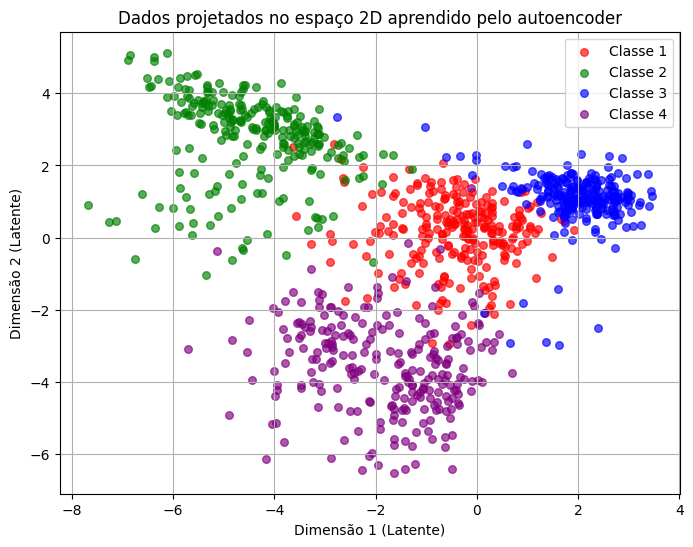

In [3]:
with torch.no_grad():
    X_latent = autoenc.encode(X_tensor).numpy()

plt.figure(figsize=(8,6))
for i, cor in zip(range(4), ['red','green','blue','purple']):
    plt.scatter(X_latent[y==i,0], X_latent[y==i,1], alpha=0.65, s=30, label=f'Classe {i+1}', c=cor)
plt.title('Dados projetados no espaço 2D aprendido pelo autoencoder')
plt.xlabel('Dimensão 1 (Latente)')
plt.ylabel('Dimensão 2 (Latente)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Discussão

- O autoencoder, ao ser treinado para reconstruir os dados 8D, aprende uma representação 2D que preserva a estrutura das classes gaussianas.
- Espera-se que os dados de cada classe formem agregados (clusters) relativamente separados no espaço latente 2D, refletindo as diferentes médias originais.
- Isso demonstra como autoencoders podem ser usados para **redução de dimensionalidade não-linear** e visualização de dados de alta dimensão.
